# Decoder scaling — speed and accuracy of the five QEC-head decoders vs system size

Doubled semion (DS), honeycomb OBC patches, QEC sign head `s(σ) = #loops(ε·σ) mod 2` with five
recovery rules `ε` (`model/decoders.py`): **anchor**, **union-find**, **greedy**, **MWPM** (production),
**tie-sum**. Two questions, two figures:

1. **Speed** — head wall-time per configuration and per VMC step vs qubit count N
   (`scripts/bench_decoders.py` microbenchmarks, several machines/code states; in-vivo `t_head`
   from production runs overlaid when present).
2. **Accuracy** — (a) exact ceilings `1 − F_s` (|ψ|²-weighted wrong-sign weight, full 2^N grading,
   `scripts/sign_fidelity.py --decoders`) vs N at fixed field; (b) achieved relative energy error of the
   trained NQS (Combo CNN + head, `cnnqB` arm, minSR lr 0.01, 350 steps, seed 0, 8192 samples) vs N at
   (h_x, h_z) = (0.4, 0); (c) V-score vs N as the optimization-budget signal.

Conventions: N = 3F + 2(Lx+Ly) − 1 qubits; `E_tail` = mean of the last 20 training energies;
rel-err = (E_tail − E_ref)/|E_ref| with `E_ref` the exact E0 where ED exists (N ≤ 27, from the
`signfid_*` gradings) and the **best variational arm** otherwise (every arm is a legitimate upper
bound; hollow markers). Head time per VMC step = µs/config × 8192 × (2 + N + F): the framed
Hamiltonian evaluates the head on the 8192 samples and on all their 1 + N + F connected configurations.

All inputs are read by glob, so cells degrade gracefully while cluster jobs are still landing —
re-execute after each `cluster.sh fetch`. Figures go to `figures/decoder_scaling/` (gitignored).

In [1]:
import os, sys, glob, re, json, pathlib
import numpy as np
import matplotlib.pyplot as plt

# house plot style (shared with the toric-code-nqs repo)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / 'results' / 'nqs').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('run this notebook from inside the 2D-TC repo')
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
FIGDIR = ROOT / 'figures' / 'decoder_scaling'; FIGDIR.mkdir(parents=True, exist_ok=True)

from model.honeycomb_geometry import HoneycombGeometry   # numpy-only

DEC = ['anchor', 'unionfind', 'greedy', 'mwpm', 'tie_sum']
DEC_LABEL = {'anchor': 'anchor', 'unionfind': 'union-find', 'greedy': 'greedy',
             'mwpm': 'MWPM (production)', 'tie_sum': 'tie-sum'}
DEC_COLOR = {'anchor': '#D55E00', 'unionfind': '#E69F00', 'greedy': '#009E73',
             'mwpm': '#0072B2', 'tie_sum': '#CC79A7'}                 # Okabe-Ito
DEC_MARK = {'anchor': 's', 'unionfind': 'D', 'greedy': '^', 'mwpm': 'o', 'tie_sum': 'v'}

_geo = {}
def geo(size):
    '''LxxLy -> (N, F, V) via the production geometry (cached).'''
    if size not in _geo:
        Lx, Ly = map(int, size.split('x')); g = HoneycombGeometry(Lx, Ly)
        _geo[size] = (g.N, g.n_plaqs, g.n_vertices)
    return _geo[size]

def steps_per_config_factor(size):
    N, F, V = geo(size); return 8192 * (2 + N + F)

## Data loaders

In [2]:
def load_ceilings():
    '''(hx, hz) -> decoder -> {size: 1 - F_s}. All `_dl` gradings at hy = 0.'''
    files = [f for f in glob.glob('results/diagnostics/signfid_hc*_ds_*_dl*.json') if '_hy' not in f]
    out = {}
    for f in files:
        d = json.load(open(f)); size = f"{d['Lx']}x{d['Ly']}"
        for p in d['points']:
            pt = (round(p['hx'], 3), round(p['hz'], 3))
            for dec, v in p['decoders'].items():
                out.setdefault(pt, {}).setdefault(dec, {})[size] = max(1.0 - v['F_s'], 0.0)
    return out

def load_e0(hx=0.4, hz=0.0):
    '''size -> exact E0 at (hx, hz) from the signfid gradings (k=1 Lanczos, ~1e-9) and results/ed.'''
    e0 = {}
    for f in glob.glob('results/diagnostics/signfid_hc*_ds*.json'):
        if '_hy' in f: continue
        d = json.load(open(f)); size = f"{d['Lx']}x{d['Ly']}"
        for p in d['points']:
            if abs(p['hx'] - hx) < 1e-9 and abs(p['hz'] - hz) < 1e-9:
                e0.setdefault(size, p['E0'])
    for f in glob.glob(f'results/ed/ed_hc*_ds_hx{hx:.2f}_hz{hz:.2f}*.json'):
        m = re.search(r'ed_hc(\d+x\d+)_', f); d = json.load(open(f))
        if m and 'E0' in d: e0.setdefault(m.group(1), d['E0'])
    return e0

def _f(x):
    return complex(str(x)).real if isinstance(x, str) else float(x)

def load_runs(hx=0.4, hz=0.0, arm='cnnqB', tail=20):
    '''(size, decoder) -> dict(E_tail, E_std, V, steps, complete, t_head, step_time, N).'''
    pat = re.compile(rf'G-equiv_1_hc(\d+x\d+)_ds_hx{hx:g}_hz{hz:g}_{arm}(?:_(\w+))?\.json$')
    runs = {}
    for f in sorted(glob.glob(f'results/nqs/G-equiv_1_hc*_ds_hx{hx:g}_hz{hz:g}_{arm}*.json')):
        m = pat.search(os.path.basename(f))
        if not m: continue
        size, dec = m.group(1), m.group(2) or 'mwpm'
        if dec not in DEC: continue
        d = json.load(open(f))
        E = np.array([_f(x) for x in d['energy']], float)
        if E.size == 0: continue
        V = np.array([_f(x) for x in d.get('Vscore', [])], float)
        th = np.array([_f(x) for x in d.get('t_head', [])], float)
        st = np.array([_f(x) for x in (d.get('step_wall') or d.get('step_time') or [])], float)
        runs[(size, dec)] = dict(
            E_tail=E[-tail:].mean(), E_std=E[-tail:].std(), steps=len(E),
            V=float(np.nanmedian(V[-tail:])) if V.size else np.nan,
            complete=os.path.exists(f.replace('.json', '.mpack')),
            t_head=float(np.median(th[-50:])) if th.size and np.nanmax(th) > 0 else np.nan,
            step_time=float(np.median(st[-50:])) if st.size else np.nan,
            N=geo(size)[0], energy=E)
    return runs

def load_bench():
    '''tag -> decoder -> workload -> density -> sorted [(N, us/config, s/step, truncated)].'''
    out = {}
    for f in sorted(glob.glob('results/diagnostics/bench_decoders_*.json')):
        d = json.load(open(f)); m = d['meta']
        api, thr = m.get('api', 'flat'), int(m.get('threads') or 1)   # legacy files: flat, 1 thread
        suffix = f"_{api}_t{thr}"
        tag = m['tag'] if ('api' not in m or m['tag'].endswith(suffix)) else f"{m['tag']}{suffix}"
        for r in d['results']:
            if not r.get('us_per_config_median'): continue
            key = round(float(r.get('density') or 0), 4)
            out.setdefault(tag, {}).setdefault(r['decoder'], {}).setdefault(r['workload'], {}) \
               .setdefault(key, []).append((r['N'], r['us_per_config_median'], r['s_per_step_equiv'], bool(r.get('truncated'))))
        out[tag]['_meta'] = {k: m.get(k) for k in ('cpu', 'git_hash', 'timestamp', 'threads_env', 'api', 'threads', 'numba_threads_effective')}
    for tag in out:
        for dec in out[tag]:
            if dec.startswith('_'): continue
            for wl in out[tag][dec]:
                for k in out[tag][dec][wl]: out[tag][dec][wl][k].sort()
    return out

def load_disagree():
    '''size -> decoder -> dict(D=sampled disagreement vs mwpm, se, D_exact=2^N |psi|^2-weighted (N<=24 only)).'''
    out = {}
    for f in glob.glob('results/diagnostics/disagree_*.json'):
        d = json.load(open(f)); g = d['geometry']; size = f"{g['Lx']}x{g['Ly']}"
        vs = d.get('disagreement', {}).get('vs_ref', {})
        ex = (d.get('exact') or {}).get('vs_ref_nqs_weighted', {})
        for dec, v in vs.items():
            out.setdefault(size, {})[dec] = dict(D=v['D'], se=max(v.get('se_chain', 0), v.get('se_binomial', 0)),
                                                 upper=v.get('rule_of_three_upper', np.nan), D_exact=ex.get(dec, np.nan))
    return out

CEIL = load_ceilings(); E0 = load_e0(); RUNS = load_runs(); BENCH = load_bench(); DIS = load_disagree()
print('ceiling field points:', sorted(CEIL)); print('sizes with exact E0 at (0.4,0):', sorted(E0, key=lambda s: geo(s)[0]))
print('runs:', len(RUNS), 'sizes', sorted({s for s, _ in RUNS}, key=lambda s: geo(s)[0]))
print('bench tags:', [t for t in BENCH]); print('disagreement files:', sorted(DIS))

ceiling field points: [(0.0, 0.0), (0.0, 0.4), (0.0, 0.8), (0.4, 0.0), (0.4, 0.4), (0.4, 0.8), (0.8, 0.0), (0.8, 0.4), (0.8, 0.8)]
sizes with exact E0 at (0.4,0): ['1x1', '1x2', '1x3', '2x2', '1x4', '1x5', '2x3']
runs: 40 sizes ['1x2', '1x3', '2x2', '1x4', '1x5', '2x3', '3x3', '4x4']
bench tags: ['laptop_asshipped', 'laptop_optimized', 'perlmutter', 'perlmutter_conn_t1', 'perlmutter_conn_t32', 'perlmutter_flat_t1', 'perlmutter_flat_t32', 'perlmutter_tiesum', 'perlmutter_tiesum_conn_t1', 'perlmutter_tiesum_flat_t1']
disagreement files: ['1x2', '1x3', '1x4', '1x5', '2x2', '2x3', '3x3']


## Figure 1 — speed: head wall time vs N (five decoders, Perlmutter)

Production hardware only (Perlmutter shared-node CPU, AMD EPYC 7763, one thread, compiled kernels —
`results/diagnostics/bench_decoders_perlmutter*.json`). Workload = production-shaped batches: base configurations
plus **all their 1+N+F connected configurations**, exactly what the framed Hamiltonian hands the head each step.
Solid curves: the production call path (`sign_pm1_conn`, hexagon-flip reuse) with 32 threads; thin dashed: the flat
single-thread API (the pre-optimization measurement). 0.5% link-flip density, the closest to the in-vivo defect density
at (0.4, 0) (0.1–0.3 defects per sample). **(a)** µs per configuration; **(b)** seconds of head time per VMC step, with the in-vivo `t_head`
medians of the production runs as large hollow markers; **(c)** density dependence at the largest size — the
tie-sum curve is non-monotonic because past its defect cap it silently falls back to MWPM.

laptop_asshipped             cpu=Apple M1 api=None threads=None (eff None) git=d1f56f70 2026-09-01T20:38:47+00:00
laptop_optimized             cpu=Apple M1 api=None threads=None (eff None) git=414e9060 2026-09-02T09:15:44+00:00
perlmutter                   cpu=AMD EPYC 7763 64-Core Processor api=None threads=None (eff None) git=a9d48388 2026-09-02T10:27:02+00:00
perlmutter_conn_t1           cpu=AMD EPYC 7763 64-Core Processor api=conn threads=1 (eff 1) git=526b75b5 2026-09-02T17:02:53+00:00
perlmutter_conn_t32          cpu=AMD EPYC 7763 64-Core Processor api=conn threads=32 (eff 32) git=af946eae 2026-09-02T18:33:09+00:00
perlmutter_flat_t1           cpu=AMD EPYC 7763 64-Core Processor api=flat threads=1 (eff 1) git=526b75b5 2026-09-02T16:56:51+00:00
perlmutter_flat_t32          cpu=AMD EPYC 7763 64-Core Processor api=flat threads=32 (eff 32) git=526b75b5 2026-09-02T17:00:46+00:00
perlmutter_tiesum            cpu=AMD EPYC 7763 64-Core Processor api=None threads=None (eff None) git=b4a7e

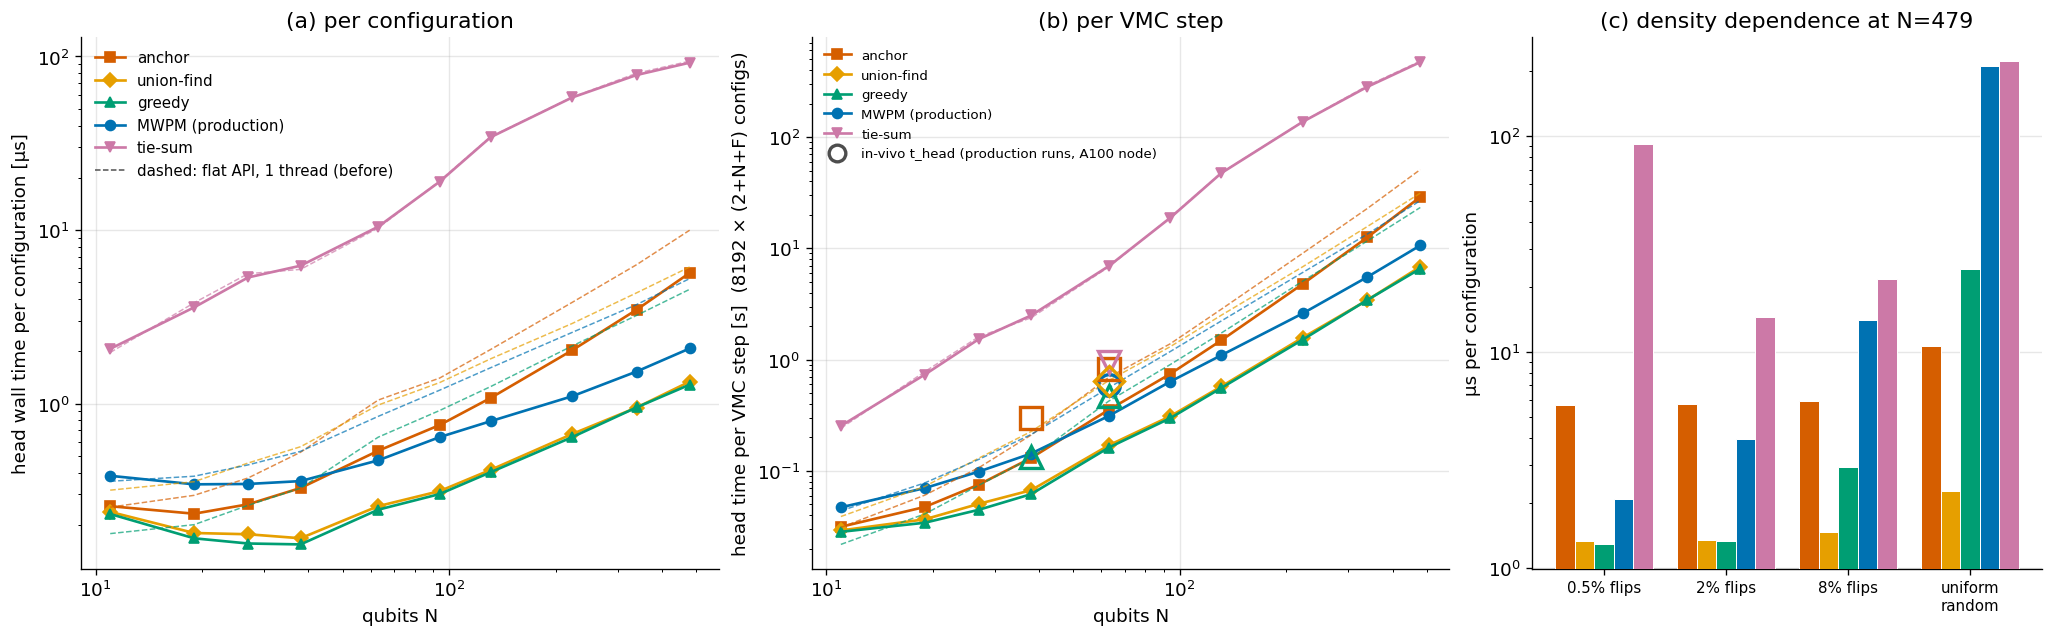

In [3]:
MAIN_TAGS = [t for t in ('perlmutter_conn_t32', 'perlmutter_tiesum_conn_t1', 'perlmutter', 'perlmutter_tiesum') if t in BENCH]
REF_TAGS  = [t for t in ('perlmutter_flat_t1', 'perlmutter_tiesum_flat_t1', 'perlmutter', 'perlmutter_tiesum') if t in BENCH]
TAGS_PM = MAIN_TAGS
DENS_MAIN = 0.005
def bench_pts(dec, dens, tags=None):
    for t in (tags or MAIN_TAGS):
        pts = BENCH[t].get(dec, {}).get('neighborhood', {}).get(dens)
        if pts: return pts
    return []

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), constrained_layout=True, gridspec_kw={'width_ratios': [1, 1, 0.8]})
for dec in DEC:
    pts = bench_pts(dec, DENS_MAIN)
    if not pts: continue
    N = [p[0] for p in pts]
    axes[0].plot(N, [p[1] for p in pts], DEC_MARK[dec] + '-', color=DEC_COLOR[dec], ms=6, lw=1.6, label=DEC_LABEL[dec])
    axes[1].plot(N, [p[2] for p in pts], DEC_MARK[dec] + '-', color=DEC_COLOR[dec], ms=6, lw=1.6, label=DEC_LABEL[dec])
if REF_TAGS and REF_TAGS[0] != MAIN_TAGS[0]:
    for dec in DEC:
        pts = bench_pts(dec, DENS_MAIN, REF_TAGS)
        if not pts: continue
        axes[0].plot([p[0] for p in pts], [p[1] for p in pts], '--', color=DEC_COLOR[dec], lw=0.9, alpha=0.7)
        axes[1].plot([p[0] for p in pts], [p[2] for p in pts], '--', color=DEC_COLOR[dec], lw=0.9, alpha=0.7)
    axes[0].plot([], [], '--', color='0.3', lw=0.9, label='dashed: flat API, 1 thread (before)')
for (size, dec), r in RUNS.items():
    if np.isfinite(r['t_head']):
        axes[1].plot(r['N'], r['t_head'], DEC_MARK[dec], color=DEC_COLOR[dec], ms=13, mfc='none', mew=2, zorder=5)
axes[1].plot([], [], 'o', color='0.3', mfc='none', ms=10, mew=2, label='in-vivo t_head (production runs, A100 node)')
for ax in axes[:2]:
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('qubits N')
axes[0].set_ylabel('head wall time per configuration [µs]'); axes[0].set_title('(a) per configuration')
axes[1].set_ylabel('head time per VMC step [s]  (8192 × (2+N+F) configs)'); axes[1].set_title('(b) per VMC step')
axes[0].legend(fontsize=9, frameon=False); axes[1].legend(fontsize=8, frameon=False, loc='upper left')
# (c) density dependence at the largest size
Nmax = max(p[0] for d in DEC for p in bench_pts(d, DENS_MAIN)) if TAGS_PM else None
dens_all = sorted({k for t in TAGS_PM for d in DEC for k in BENCH[t].get(d, {}).get('neighborhood', {})})
if Nmax:
    w = 0.8 / len(DEC); x = np.arange(len(dens_all) + 1)
    for k, dec in enumerate(DEC):
        vals = []
        for dn in dens_all:
            v = [p[1] for p in bench_pts(dec, dn) if p[0] == Nmax]; vals.append(v[0] if v else np.nan)
        uni = [r for t in TAGS_PM for r in [] ]
        # uniform-random column from the raw results
        u = [rr['us_per_config_median'] for t in TAGS_PM for rr in json.load(open(f'results/diagnostics/bench_decoders_{t}.json'))['results']
             if rr['decoder'] == dec and rr['workload'] == 'uniform' and rr['N'] == Nmax and rr.get('us_per_config_median')]
        vals.append(u[0] if u else np.nan)
        axes[2].bar(x + (k - 2) * w, vals, w, color=DEC_COLOR[dec], label=DEC_LABEL[dec], edgecolor='white', lw=0.6, zorder=3)
    axes[2].set_yscale('log'); axes[2].set_xticks(x); axes[2].set_xticklabels([f'{100*d:g}% flips' for d in dens_all] + ['uniform\nrandom'], fontsize=9)
    axes[2].set_ylabel('µs per configuration'); axes[2].set_title(f'(c) density dependence at N={Nmax}'); axes[2].grid(axis='x'); axes[2].set_axisbelow(True)
fig.savefig(FIGDIR / 'fig1_speed_vs_N.png', dpi=200, bbox_inches='tight')
for t in sorted(BENCH):
    m = BENCH[t]['_meta']; print(f"{t:28s} cpu={(m.get('cpu') or {}).get('model_name')} api={m.get('api','flat')} threads={m.get('threads',1)} (eff {m.get('numba_threads_effective')}) git={str(m.get('git_hash'))[:8]} {m.get('timestamp')}")

### Speed — numeric table (Perlmutter)

µs per configuration → seconds of head time per VMC step at the 0.5% (in-vivo-like) and 2% flip densities.
The compiled-vs-shipped speed-up (greedy 6–16×, union-find 4–22×, anchor 1.3–3.3×, MWPM ~1.3×) was measured
on the laptop (`bench_decoders_laptop_{asshipped,optimized}.json`) and is not plotted here.

In [4]:
for dens in (0.005, 0.02):
    rows = {}
    for dec in DEC:
        for N, us, sps, tr in bench_pts(dec, dens):
            rows.setdefault(N, {})[dec] = (us, sps, tr)
    print(f"\n## Perlmutter, {100*dens:g}% flips:  us/config -> s per VMC step   [T = budget-truncated]")
    print(f"{'N':>5s} | " + " | ".join(f"{d:>19s}" for d in DEC))
    for N in sorted(rows):
        print(f"{N:5d} | " + " | ".join(f"{rows[N][d][0]:7.2f} -> {rows[N][d][1]:7.2f}{'T' if rows[N][d][2] else ' '}" if d in rows[N] else ' ' * 19 for d in DEC))


## Perlmutter, 0.5% flips:  us/config -> s per VMC step   [T = budget-truncated]
    N |              anchor |           unionfind |              greedy |                mwpm |             tie_sum
   11 |    0.26 ->    0.03  |    0.24 ->    0.03  |    0.23 ->    0.03  |    0.38 ->    0.05  |    2.07 ->    0.25 
   19 |    0.23 ->    0.05  |    0.18 ->    0.04  |    0.17 ->    0.03  |    0.34 ->    0.07  |    3.58 ->    0.73 
   27 |    0.26 ->    0.08  |    0.18 ->    0.05  |    0.16 ->    0.04  |    0.34 ->    0.10  |    5.33 ->    1.53 
   38 |    0.33 ->    0.13  |    0.17 ->    0.07  |    0.15 ->    0.06  |    0.36 ->    0.14  |    6.22 ->    2.50 
   63 |    0.53 ->    0.35  |    0.26 ->    0.17  |    0.24 ->    0.16  |    0.47 ->    0.31  |   10.45 ->    6.93 
   94 |    0.75 ->    0.74  |    0.31 ->    0.31  |    0.30 ->    0.30  |    0.64 ->    0.63  |   18.98 ->   18.81 
  131 |    1.08 ->    1.49  |    0.41 ->    0.57  |    0.40 ->    0.56  |    0.79 ->    1.10  |   34.25 ->

### Head time per step during training (in vivo)

`t_head` per step from the production runs that log it. This is where tie_sum's transient shows: far-from-ground-
state samples early in training carry many defects, so its class enumeration is expensive (tens of seconds per
step); on the plateau it drops to ~1 s. The four fast decoders are flat from step 1.

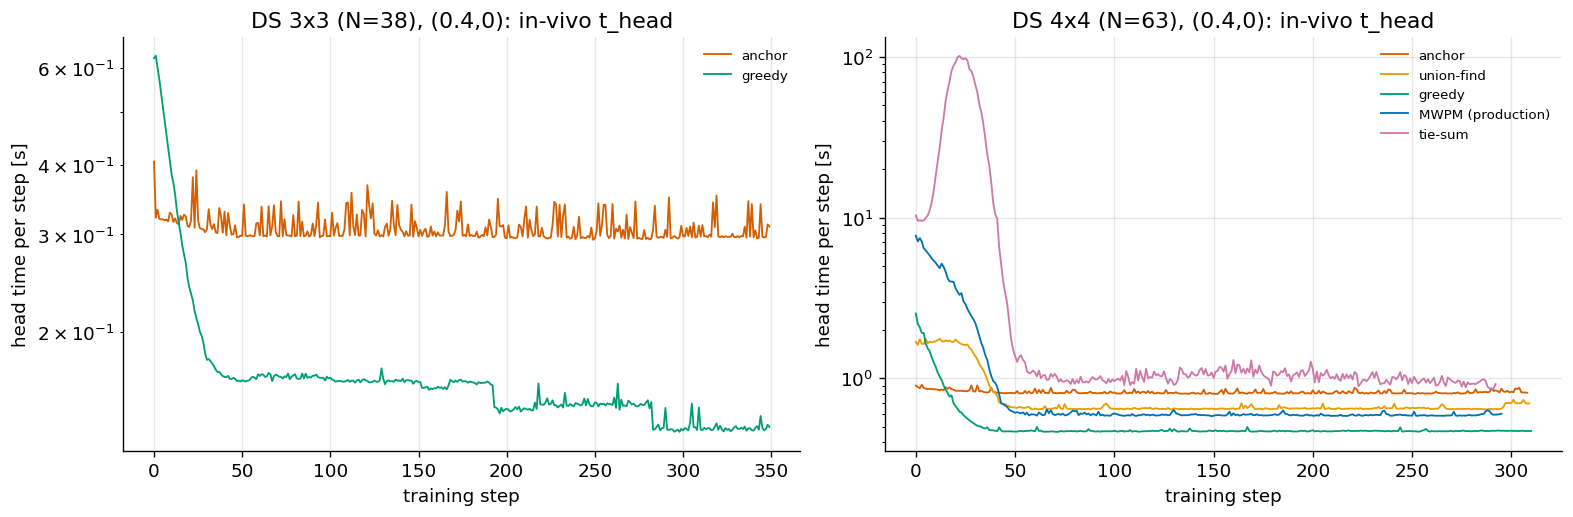

In [5]:
sizes_th = sorted({s for (s, d), r in RUNS.items() if np.isfinite(r['t_head'])}, key=lambda s: geo(s)[0])
if sizes_th:
    fig, axes = plt.subplots(1, len(sizes_th), figsize=(6.5 * len(sizes_th), 4.2), constrained_layout=True, squeeze=False)
    for ax, s in zip(axes[0], sizes_th):
        for dec in DEC:
            r = RUNS.get((s, dec))
            if r is None: continue
            f = f"results/nqs/G-equiv_1_hc{s}_ds_hx0.4_hz0_cnnqB{'' if dec == 'mwpm' else '_' + dec}.json"
            th = np.array([_f(x) for x in json.load(open(f)).get('t_head', [])], float)
            if th.size and np.nanmax(th) > 0:
                ax.plot(np.arange(len(th)), th, color=DEC_COLOR[dec], lw=1.1, label=DEC_LABEL[dec])
        ax.set_yscale('log'); ax.set(xlabel='training step', ylabel='head time per step [s]',
                                     title=f'DS {s} (N={geo(s)[0]}), (0.4,0): in-vivo t_head')
        ax.legend(fontsize=8, frameon=False)
    fig.savefig(FIGDIR / 'fig1b_t_head_vs_step.png', dpi=200, bbox_inches='tight')
else:
    print('no run logs t_head yet')

## Figure 2 — accuracy vs N

**(a)** exact ceilings `1 − F_s` per decoder at three field points (every size with a full 2^N grading);
**(b)** achieved relative energy error at (0.4, 0): filled = vs exact E0, hollow = vs the best arm at that
size (no ED; arms cut by walltime after ≥200 steps count as converged), × = incomplete run (partial trajectory), dotted = that decoder's exact ceiling at (0.4, 0)
for direct comparison; **(c)** V-score (N·Var/⟨E⟩²) of the same runs — the budget signal.
Sampled disagreement-vs-MWPM proxies (`disagree_*.json`) are overlaid on (a) as small crosses when present.

{'1x2': (-12.32884367, 'ED'), '1x3': (-17.46543148, 'ED'), '2x2': (-20.5227498, 'ED'), '1x4': (-22.60200964, 'ED'), '1x5': (-27.73858959, 'ED'), '2x3': (-28.71896299, 'ED'), '3x3': (np.float64(-39.96076747), 'best'), '4x4': (np.float64(-65.51683653), 'best')}


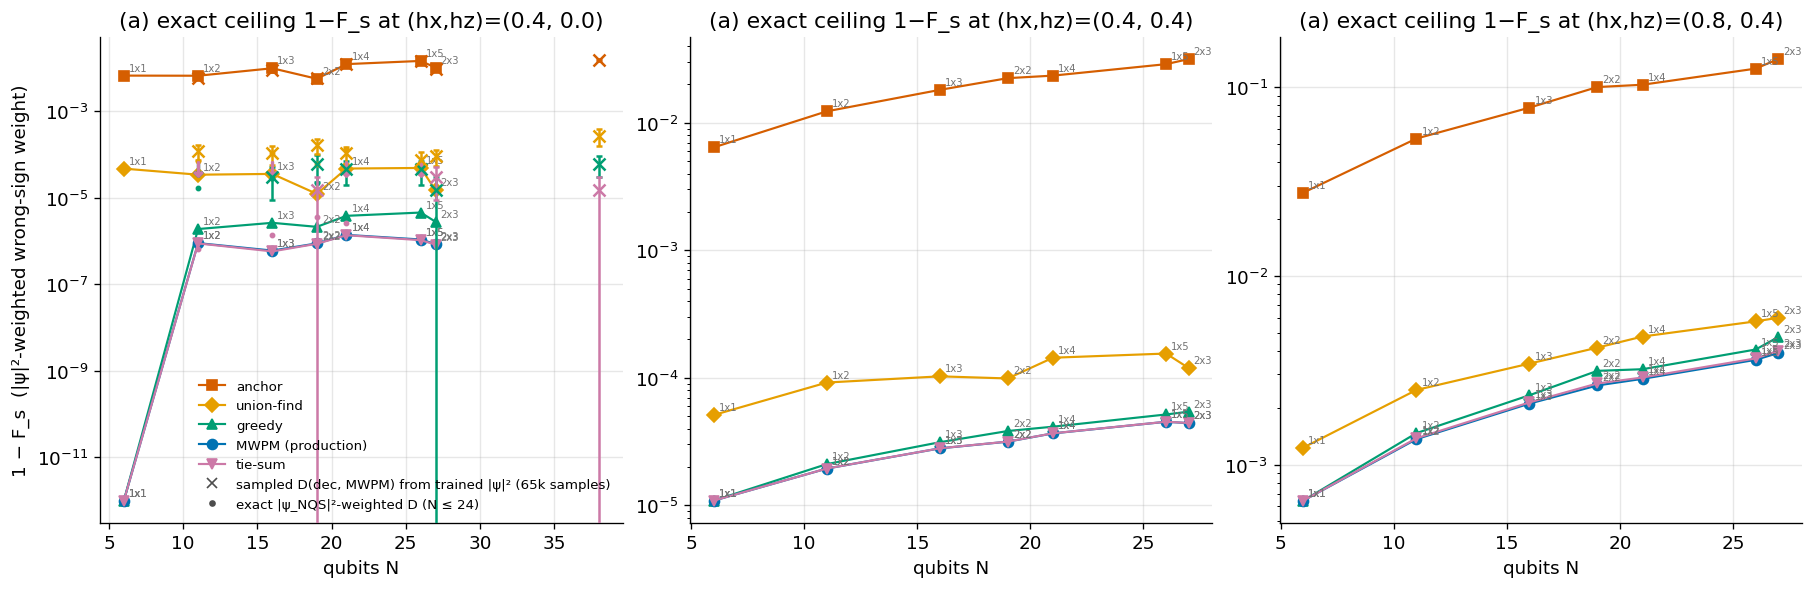

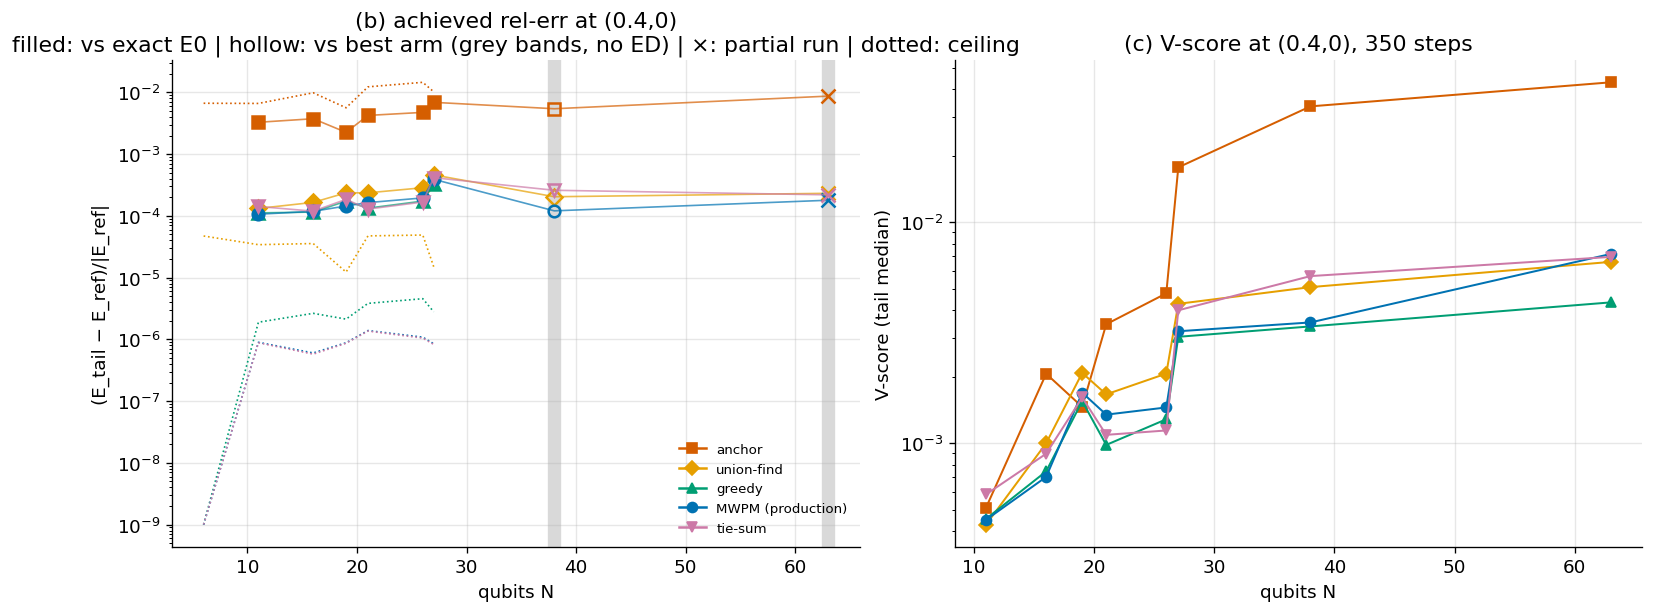

In [6]:
PTS = [(0.4, 0.0), (0.4, 0.4), (0.8, 0.4)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
# (a) ceilings
for ax, pt in zip(axes, PTS):
    for dec in DEC:
        sz = CEIL.get(pt, {}).get(dec, {})
        if not sz: continue
        items = sorted(sz.items(), key=lambda kv: geo(kv[0])[0])
        N = [geo(s)[0] for s, _ in items]; y = [max(v, 1e-12) for _, v in items]
        ax.plot(N, y, DEC_MARK[dec] + '-', color=DEC_COLOR[dec], ms=6, lw=1.3, label=DEC_LABEL[dec])
        for (s, v), n in zip(items, N):
            ax.annotate(s, (n, max(v, 1e-12)), fontsize=6, xytext=(3, 3), textcoords='offset points', color='0.45')
    if pt == (0.4, 0.0):
        for size, dd in DIS.items():
            for dec, v in dd.items():
                if dec not in DEC or dec == 'mwpm': continue
                n = geo(size)[0]
                if v['D'] > 0:
                    ax.errorbar(n, v['D'], yerr=v['se'], fmt='x', color=DEC_COLOR[dec], ms=7, mew=1.5, capsize=2, zorder=4)
                else:   # zero sampled disagreements: rule-of-three upper bound as a down-arrow
                    ax.plot(n, v['upper'], marker=r'$\downarrow$', color=DEC_COLOR[dec], ms=9, ls='none', zorder=4)
                if np.isfinite(v.get('D_exact', np.nan)) and v['D_exact'] > 0:
                    ax.plot(n, v['D_exact'], '.', color=DEC_COLOR[dec], ms=5, zorder=4)
        ax.plot([], [], 'x', color='0.3', label='sampled D(dec, MWPM) from trained |ψ|² (65k samples)')
        ax.plot([], [], '.', color='0.3', label='exact |ψ_NQS|²-weighted D (N ≤ 24)')
    ax.set_yscale('log'); ax.set_xlabel('qubits N'); ax.set_title(f'(a) exact ceiling 1−F_s at (hx,hz)={pt}')
axes[0].set_ylabel('1 − F_s  (|ψ|²-weighted wrong-sign weight)'); axes[0].legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / 'fig2a_ceilings_vs_N.png', dpi=200, bbox_inches='tight')
# (b) achieved rel-err at (0.4,0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
ax = axes[0]
sizes = sorted({s for s, _ in RUNS}, key=lambda s: geo(s)[0])
ref = {}
for s in sizes:
    if s in E0: ref[s] = (E0[s], 'ED')
    else:
        done = [r['E_tail'] for (ss, d), r in RUNS.items() if ss == s and (r['complete'] or r['steps'] >= 200)]   # walltime-cut runs past step 200 are on plateau
        if done: ref[s] = (min(done), 'best')
for dec in DEC:
    xs, ys, kinds = [], [], []
    for s in sizes:
        r = RUNS.get((s, dec));
        if r is None or s not in ref: continue
        e0, kind = ref[s]; rel = (r['E_tail'] - e0) / abs(e0)
        if kind == 'best' and rel <= 0: continue          # the reference arm itself
        xs.append(r['N']); ys.append(max(rel, 1e-9)); kinds.append((kind, r['complete']))
    ax.plot(xs, ys, '-', color=DEC_COLOR[dec], lw=1.0, alpha=0.7)
    for x, y, (kind, comp) in zip(xs, ys, kinds):
        ax.plot(x, y, 'x' if not comp else DEC_MARK[dec], color=DEC_COLOR[dec], ms=7 if comp else 8,
                mfc=DEC_COLOR[dec] if kind == 'ED' else 'none', mew=1.5)
    ax.plot([], [], DEC_MARK[dec] + '-', color=DEC_COLOR[dec], label=DEC_LABEL[dec])
    c = CEIL.get((0.4, 0.0), {}).get(dec, {})
    if c:
        items = sorted(c.items(), key=lambda kv: geo(kv[0])[0])
        ax.plot([geo(s)[0] for s, _ in items], [max(v, 1e-9) for _, v in items], ':', color=DEC_COLOR[dec], lw=1.0)
for s in sizes:
    if s in ref and ref[s][1] == 'best':
        ax.axvline(geo(s)[0], color='0.85', lw=8, zorder=0)
ax.set_yscale('log'); ax.set_xlabel('qubits N'); ax.set_ylabel('(E_tail − E_ref)/|E_ref|')
ax.set_title('(b) achieved rel-err at (0.4,0)\nfilled: vs exact E0 | hollow: vs best arm (grey bands, no ED) | ×: partial run | dotted: ceiling')
ax.legend(fontsize=8, frameon=False)
# (c) V-score
ax = axes[1]
for dec in DEC:
    pts = sorted([(r['N'], r['V']) for (s, d), r in RUNS.items() if d == dec and np.isfinite(r['V'])])
    if pts: ax.plot([p[0] for p in pts], [p[1] for p in pts], DEC_MARK[dec] + '-', color=DEC_COLOR[dec], ms=6, lw=1.2, label=DEC_LABEL[dec])
ax.set_yscale('log'); ax.set_xlabel('qubits N'); ax.set_ylabel('V-score (tail median)'); ax.set_title('(c) V-score at (0.4,0), 350 steps')
fig.savefig(FIGDIR / 'fig2b_relerr_vscore_vs_N.png', dpi=200, bbox_inches='tight')
print({s: (round(v, 8), k) for s, (v, k) in ref.items()})

### Exact ceilings — numeric table (1 − F_s per decoder, three field points)

In [7]:
for pt in PTS:
    print(f"\n## (hx,hz) = {pt}")
    print(f"{'size':5s}{'N':>4s} | " + " | ".join(f"{d:>10s}" for d in DEC))
    szs = sorted({s for d in DEC for s in CEIL.get(pt, {}).get(d, {})}, key=lambda s: geo(s)[0])
    for sz in szs:
        print(f"{sz:5s}{geo(sz)[0]:4d} | " + " | ".join(f"{CEIL[pt].get(d, {}).get(sz, np.nan):10.2e}" for d in DEC))


## (hx,hz) = (0.4, 0.0)
size    N |     anchor |  unionfind |     greedy |       mwpm |    tie_sum
1x1     6 |   6.68e-03 |   4.72e-05 |   0.00e+00 |   0.00e+00 |   0.00e+00
1x2    11 |   6.63e-03 |   3.42e-05 |   1.89e-06 |   8.96e-07 |   8.81e-07
1x3    16 |   9.86e-03 |   3.56e-05 |   2.64e-06 |   6.02e-07 |   5.76e-07
2x2    19 |   5.64e-03 |   1.23e-05 |   2.13e-06 |   8.81e-07 |   8.65e-07
1x4    21 |   1.23e-02 |   4.74e-05 |   3.83e-06 |   1.39e-06 |   1.36e-06
1x5    26 |   1.46e-02 |   4.89e-05 |   4.56e-06 |   1.09e-06 |   1.05e-06
2x3    27 |   1.02e-02 |   1.50e-05 |   2.79e-06 |   8.48e-07 |   8.28e-07

## (hx,hz) = (0.4, 0.4)
size    N |     anchor |  unionfind |     greedy |       mwpm |    tie_sum
1x1     6 |   6.42e-03 |   5.11e-05 |   1.09e-05 |   1.09e-05 |   1.09e-05
1x2    11 |   1.23e-02 |   9.18e-05 |   2.10e-05 |   1.94e-05 |   1.94e-05
1x3    16 |   1.81e-02 |   1.03e-04 |   3.12e-05 |   2.80e-05 |   2.80e-05
2x2    19 |   2.24e-02 |   9.88e-05 |   3.82e-05 |

## Ceiling proxy beyond ED — sampled sign-disagreement vs MWPM

`scripts/decoder_disagreement.py` samples σ ~ |ψ|² from the trained MWPM arm and evaluates all five heads on the same
samples. D(dec, MWPM) counts both directions, so for the near-exact decoders it over-estimates 1−F_s (it includes MWPM's
own tie errors and the configurations where the decoder is right and MWPM wrong); for anchor it reproduces the exact
ceiling. Columns: sampled D ± chain SE, the exact |ψ_NQS|²-weighted D (N ≤ 24), the true 1−F_s from the ED grading.

In [8]:
print(f"{'size':5s}{'N':>4s} {'decoder':11s} {'D sampled':>11s} {'± se':>9s} {'D exact(NQS)':>13s} {'true 1-F_s':>11s}")
for size in sorted(DIS, key=lambda s: geo(s)[0]):
    for dec in DEC:
        v = DIS[size].get(dec)
        if v is None or dec == 'mwpm': continue
        c = CEIL.get((0.4, 0.0), {}).get(dec, {}).get(size, np.nan)
        print(f"{size:5s}{geo(size)[0]:4d} {dec:11s} {v['D']:11.2e} {v['se']:9.1e} {v.get('D_exact', np.nan):13.2e} {c:11.2e}")

size    N decoder       D sampled      ± se  D exact(NQS)  true 1-F_s
1x2    11 anchor         6.01e-03   5.6e-04      6.46e-03    6.63e-03
1x2    11 unionfind      1.22e-04   4.8e-05      7.03e-05    3.42e-05
1x2    11 greedy         0.00e+00   0.0e+00      1.66e-05    1.89e-06
1x2    11 tie_sum        0.00e+00   0.0e+00      6.58e-07    8.81e-07
1x3    16 anchor         8.79e-03   6.2e-04      9.63e-03    9.86e-03
1x3    16 unionfind      1.07e-04   5.1e-05      1.08e-04    3.56e-05
1x3    16 greedy         3.05e-05   2.2e-05      2.94e-05    2.64e-06
1x3    16 tie_sum        0.00e+00   0.0e+00      1.35e-06    5.76e-07
2x2    19 anchor         5.92e-03   4.4e-04      5.49e-03    5.64e-03
2x2    19 unionfind      1.68e-04   6.6e-05      6.15e-05    1.23e-05
2x2    19 greedy         6.10e-05   3.7e-05      2.23e-05    2.13e-06
2x2    19 tie_sum        1.53e-05   1.5e-05      3.68e-06    8.65e-07
1x4    21 anchor         1.23e-02   7.0e-04      1.21e-02    1.23e-02
1x4    21 unionfind 

## Numeric table — every run at (0.4, 0)

In [9]:
print(f"{'size':5s}{'N':>4s} {'decoder':11s}{'steps':>6s} {'E_tail':>14s} {'E_std':>8s} {'V-score':>9s} {'rel-err':>10s} {'ref':>5s} {'ceiling':>9s} {'t_head':>7s} {'s/step':>7s} done")
for s in sizes:
    for dec in DEC:
        r = RUNS.get((s, dec))
        if r is None: continue
        e0, kind = ref.get(s, (np.nan, '—')); rel = (r['E_tail'] - e0) / abs(e0) if np.isfinite(e0) else np.nan
        c = CEIL.get((0.4, 0.0), {}).get(dec, {}).get(s, np.nan)
        print(f"{s:5s}{r['N']:4d} {dec:11s}{r['steps']:6d} {r['E_tail']:14.8f} {r['E_std']:8.1e} {r['V']:9.1e} {rel:10.2e} {kind:>5s} {c:9.1e} {r['t_head']:7.2f} {r['step_time']:7.2f} {'Y' if r['complete'] else 'partial'}")
    if s in ref: print(f"      E_ref({s}) = {ref[s][0]:.10f} [{ref[s][1]}]")

size    N decoder     steps         E_tail    E_std   V-score    rel-err   ref   ceiling  t_head  s/step done
1x2    11 anchor        350   -12.28838392  2.8e-03   5.1e-04   3.28e-03    ED   6.6e-03     nan     nan Y
1x2    11 unionfind     350   -12.32721569  1.1e-03   4.3e-04   1.32e-04    ED   3.4e-05     nan     nan Y
1x2    11 greedy        350   -12.32746529  1.9e-03   4.5e-04   1.12e-04    ED   1.9e-06     nan     nan Y
1x2    11 mwpm          350   -12.32753219  1.3e-03   4.5e-04   1.06e-04    ED   9.0e-07     nan     nan Y
1x2    11 tie_sum       350   -12.32709388  1.3e-03   5.9e-04   1.42e-04    ED   8.8e-07     nan     nan Y
      E_ref(1x2) = -12.3288436697 [ED]
1x3    16 anchor        350   -17.39999768  4.7e-03   2.1e-03   3.75e-03    ED   9.9e-03     nan     nan Y
1x3    16 unionfind     350   -17.46254294  1.9e-03   1.0e-03   1.65e-04    ED   3.6e-05     nan     nan Y
1x3    16 greedy        350   -17.46341974  1.5e-03   7.5e-04   1.15e-04    ED   2.6e-06     nan     n

## Learning curves at the largest size with all five arms

Energy vs step (same seed/recipe); the dashed line is the reference energy for that size.

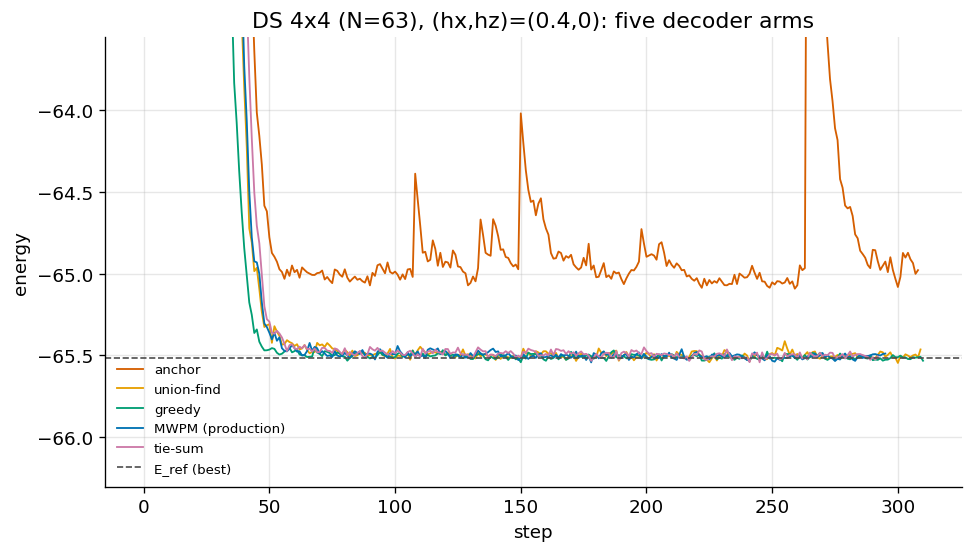

In [10]:
full = [s for s in sizes if all((s, d) in RUNS for d in DEC)]
if full:
    s = full[-1]
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for dec in DEC:
        E = RUNS[(s, dec)]['energy']; ax.plot(np.arange(len(E)), E, color=DEC_COLOR[dec], lw=1.1, label=DEC_LABEL[dec])
    if s in ref: ax.axhline(ref[s][0], color='0.3', ls='--', lw=1, label=f"E_ref ({ref[s][1]})")
    lo = min(RUNS[(s, d)]['E_tail'] for d in DEC); ax.set_ylim(lo - 0.06 * abs(lo) * 0.2, lo + 0.03 * abs(lo))
    ax.set(xlabel='step', ylabel='energy', title=f'DS {s} (N={geo(s)[0]}), (hx,hz)=(0.4,0): five decoder arms')
    ax.legend(fontsize=8, frameon=False)
    fig.savefig(FIGDIR / f'learning_curves_{s}.png', dpi=200, bbox_inches='tight')
else:
    print('no size has all five arms yet')

## Figure 3 — in-vivo total VMC step time vs N: GPU-only baseline and the five head arms

Timing ladder (`jobs/nersc_timing_ladder.sh`, jobids `*_tim_*`): the same positive Combo network and DS
Hamiltonian at **(0.8, 0.4)** — chosen to stress the head (more defects per sample than the accuracy point) — 100 steps each, on one A100 shared-node slice. Arm `cnn` has NO sign head — its
`step_wall` is the GPU-only cost (sampling + 8192·(2+N+F) network forwards + minSR). The five head arms add
the head's serial CPU time; since the branches are sequential, total = GPU + head exactly, and each curve's
lift above the grey baseline is that decoder's cost. Plateau medians over steps 50–100 (the JIT step and
tie-sum's early transient excluded). **(a)** total step time; **(b)** the same runs with the measured head time
subtracted — if the head is purely additive these collapse onto the GPU-only curve, and the residual scatter is
the node-to-node noise of the shared queue (different jobs land on different nodes); **(c)** the head's share
t_head / step_wall, which is immune to that noise.

size    N arm         step_wall   t_head   share  steps
1x2    11 cnn              0.35     0.00   0.000    100
1x2    11 anchor           0.36     0.02   0.044    100
1x2    11 unionfind        0.36     0.01   0.022    100
1x2    11 greedy           0.35     0.01   0.021    100
1x2    11 mwpm             0.37     0.03   0.082    100
1x2    11 tie_sum          0.37     0.04   0.118    100
2x2    19 cnn              1.81     0.00   0.000    100
2x2    19 anchor           2.02     0.04   0.021    100
2x2    19 unionfind        1.96     0.02   0.011    100
2x2    19 greedy           1.94     0.02   0.010    100
2x2    19 mwpm             1.85     0.07   0.037    100
2x2    19 tie_sum          1.89     0.13   0.071    100
2x3    27 cnn              4.11     0.00   0.000    100
2x3    27 anchor           5.72     0.07   0.013    100
2x3    27 unionfind        4.15     0.04   0.009    100
2x3    27 greedy           3.93     0.04   0.009    100
2x3    27 mwpm             4.33     0.12   0.029

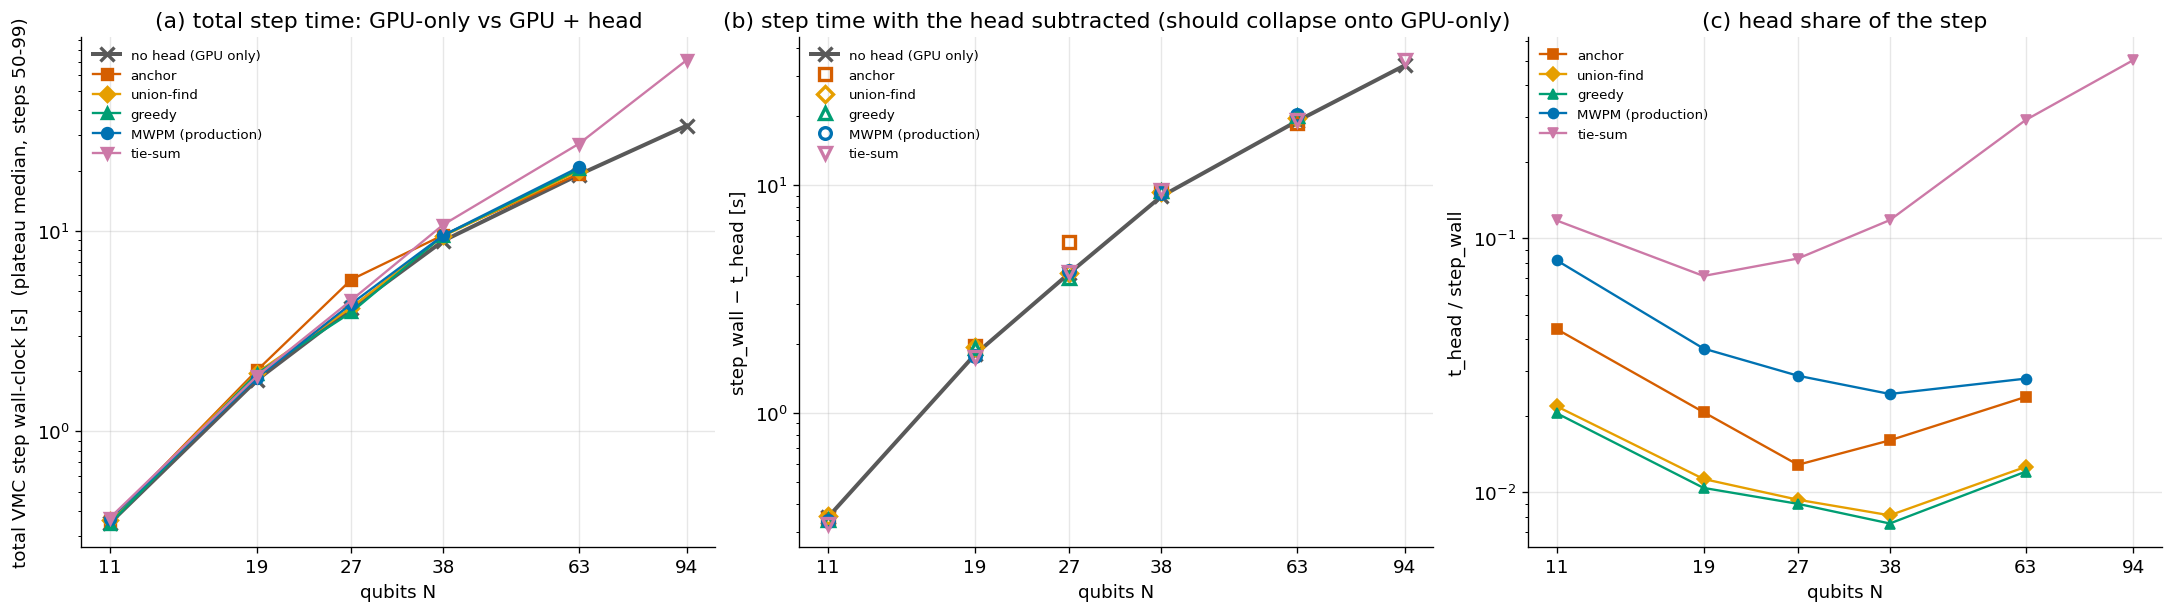

In [11]:
def load_timing(hx=0.8, hz=0.4, lo=50):
    # (size, arm) -> dict(step_wall, t_head, steps, N) from the *_tim_* runs (plateau medians over steps >= lo)
    pat = re.compile(rf'G-equiv_1_hc(\d+x\d+)_ds_hx{hx:g}_hz{hz:g}_tim_(cnn|cnnqB)(?:_(\w+))?\.json$')
    out = {}
    for f in sorted(glob.glob(f'results/nqs/G-equiv_1_hc*_ds_hx{hx:g}_hz{hz:g}_tim_*.json')):
        m = pat.search(os.path.basename(f))
        if not m: continue
        size = m.group(1); arm = 'cnn' if m.group(2) == 'cnn' else (m.group(3) or 'mwpm')
        d = json.load(open(f))
        sw = np.array([_f(x) for x in d.get('step_wall', [])], float)
        th = np.array([_f(x) for x in d.get('t_head', [])], float)
        if sw.size <= lo: continue
        out[(size, arm)] = dict(step_wall=float(np.median(sw[lo:])), t_head=float(np.median(th[lo:])) if th.size > lo else 0.0,
                                steps=len(sw), N=geo(size)[0], complete=os.path.exists(f.replace('.json', '.mpack')))
    return out

TIM = load_timing()
if TIM:
    ARMS6 = ['cnn'] + DEC
    LAB6 = {'cnn': 'no head (GPU only)', **DEC_LABEL}; COL6 = {'cnn': '0.35', **DEC_COLOR}; MK6 = {'cnn': 'x', **DEC_MARK}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for arm in ARMS6:
        pts = sorted([(r['N'], r['step_wall'], r['t_head']) for (s, a), r in TIM.items() if a == arm])
        if not pts: continue
        N = [p[0] for p in pts]
        big = arm == 'cnn'
        axes[0].plot(N, [p[1] for p in pts], MK6[arm] + '-', color=COL6[arm], ms=8 if big else 6, lw=2.4 if big else 1.4, label=LAB6[arm], mew=2)
        axes[1].plot(N, [p[1] - p[2] for p in pts], MK6[arm] + ('-' if big else ''), color=COL6[arm], ms=8 if big else 7, lw=2.4 if big else 0, label=LAB6[arm], mew=2, mfc='none' if not big else COL6[arm])
        if not big:
            axes[2].plot(N, [p[2] / p[1] for p in pts], MK6[arm] + '-', color=COL6[arm], ms=6, lw=1.4, label=LAB6[arm])
    from matplotlib.ticker import FixedLocator, NullLocator, ScalarFormatter
    Ns = sorted({r['N'] for r in TIM.values()})
    for ax in axes:
        ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('qubits N')
        ax.xaxis.set_major_locator(FixedLocator(Ns)); ax.xaxis.set_minor_locator(NullLocator())
        ax.xaxis.set_major_formatter(ScalarFormatter()); ax.set_xticklabels([str(n) for n in Ns])
    axes[0].set_ylabel('total VMC step wall-clock [s]  (plateau median, steps 50-99)')
    axes[0].set_title('(a) total step time: GPU-only vs GPU + head'); axes[0].legend(fontsize=8, frameon=False)
    axes[1].set_ylabel('step_wall − t_head [s]')
    axes[1].set_title('(b) step time with the head subtracted (should collapse onto GPU-only)'); axes[1].legend(fontsize=8, frameon=False)
    axes[2].set_ylabel('t_head / step_wall'); axes[2].set_title('(c) head share of the step'); axes[2].legend(fontsize=8, frameon=False)
    fig.savefig(FIGDIR / 'fig3_step_time_vs_N.png', dpi=200, bbox_inches='tight')
    print(f"{'size':5s}{'N':>4s} {'arm':10s} {'step_wall':>10s} {'t_head':>8s} {'share':>7s} {'steps':>6s}")
    for (s, a), r in sorted(TIM.items(), key=lambda kv: (geo(kv[0][0])[0], ARMS6.index(kv[0][1]))):
        print(f"{s:5s}{r['N']:4d} {a:10s} {r['step_wall']:10.2f} {r['t_head']:8.2f} {r['t_head']/r['step_wall']:7.3f} {r['steps']:6d}")
else:
    print('no timing-ladder runs (*_tim_*) with step_wall yet')

## Verdict (campaign of 2026-09-02)

**Speed.** The four fast decoders scale ≈ N² per VMC step (µs/config roughly linear in N) and stay within a
factor of two of each other at every size: greedy fastest, MWPM within ~30% of it with no approximation,
union-find and anchor in between. On Perlmutter the head costs 0.16 s/step at N=27 and 28–50 s/step at
N=479; in vivo at 4×4 it is 0.5–0.8 s of a ~21 s step (3–4%), so the GPU side dominates at every size reached.
The compiled kernels bought 12× (greedy) and 17× (union-find) over the shipped Python at N=63 and removed the
2^F / N≤62 size caps. tie_sum is 25–100× slower in the benchmark and, in vivo, spends tens of seconds per step
while the state is far from the ground state (many defects ⇒ large minimal classes) before settling to ~1 s.

**Accuracy.** Exact ceilings 1−F_s at seven sizes (N = 6…27): MWPM ≈ tie_sum flat ≈ 1e-6, greedy ≈ 3e-6,
union-find 1–5e-5, anchor 6e-3…1.5e-2 growing with the patch (its GF(2)-linear channel); at strong field every
ceiling grows ≈ linearly with N. In vivo (350 steps, seed 0) anchor lands at 30–70% of its ceiling —
ceiling-limited — and is 30–50× worse than the rest at every N up to 63. Union-find, greedy, MWPM and tie_sum
are statistically indistinguishable (single seed), with achieved rel-err rising 1e-4 → 4e-4 from N=11 to 27,
two to three orders ABOVE their ceilings: budget-limited, not decoder-limited. The sampled disagreement proxy
reproduces anchor's ceiling to a few % and bounds the others from above by 3–10×, so it can grade decoders where
ED cannot.

**Reference beyond ED.** No published method benchmarks DS + h_x at any size (sign-free QMC needs frozen flux,
which σˣ hops — `docs/benchmark_feasibility.md`); the best variational arm is the reference at N = 38, 63.
A self-built strip DMRG is the next trusted benchmark. Follow-ups: seed replicas; 350-step 4×4 parity reruns;
row-parallel numba and decode reuse for hexagon-flip neighbours (untouched head speed levers).